<a href="https://colab.research.google.com/github/pkorotkow/statprak/blob/main/statprak2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework

## Problem 1

Let $f(x) = 2\sin x - \cos{2x}$. Write a function `beauty_derivative_plot` that takes a point $x$ and plots the function $f(x)$ and its derivative $f'(x)$ in the range $x \in [-2\pi, 2\pi]$. The function should also plot the tangent line to the function at the point $x$.

Example of output for $x = -3, -2, 1.7$:

```python
beauty_derivative_plot(-3)
```
<img src="https://i.ibb.co/zTdYLC0J/tangent-line-3-0.png" width="600"/>

```python
beauty_derivative_plot(-2)
```
<img src="https://i.ibb.co/hFXNZ7wS/tangent-line-2-0.png" width="600"/>

```python
beauty_derivative_plot(1.7)
```
<img src="https://i.ibb.co/217yHstn/tangent-line-1-7.png" width="600"/>

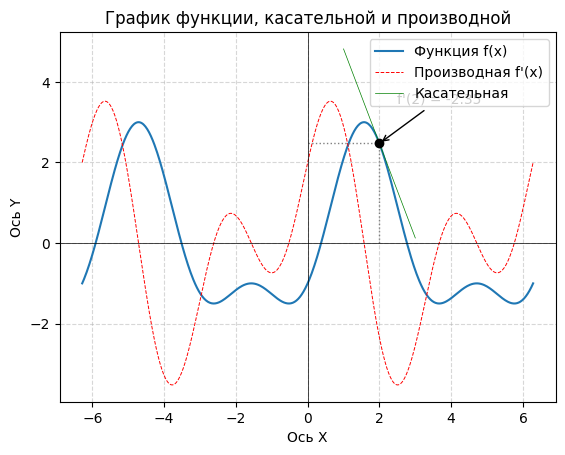

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def beauty_derivative_plot(x):
    X = np.linspace(-2 * np.pi, 2 * np.pi, 500)
    X_tangent = np.linspace(x - 1, x + 1, 100)
    y = 2 * np.sin(X) - np.cos(2 * X)
    y_der = 2 * np.cos(X) + 2 * np.sin(2 * X)

    f_x = 2 * np.sin(x) - np.cos(2 * x)
    df_x = 2 * np.cos(x) + 2 * np.sin(2 * x)

    plt.plot(X, y, label='Функция f(x)')
    plt.plot(X, y_der, color='r', lw=0.7, ls='--', label="Производная f'(x)")

    y_tangent = df_x * (X_tangent - x) + f_x
    plt.plot(X_tangent, y_tangent, color='green', lw=0.5, label='Касательная')

    plt.vlines(x, 0, f_x, color='gray', linestyle=':', lw=1)
    plt.hlines(f_x, 0, x, color='gray', linestyle=':', lw=1)
    plt.scatter([x], [f_x], color='black', zorder=3)

    plt.annotate(f"f'({x}) = {df_x:.2f}",
                 xy=(x, f_x),
                 xytext=(x + 0.5, f_x + 1),
                 arrowprops=dict(arrowstyle='->', color='black'))

    plt.title('График функции, касательной и производной')
    plt.xlabel('Ось X')
    plt.ylabel('Ось Y')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)

    plt.legend()
    plt.show()

beauty_derivative_plot(2)

## Problem 2

The data in [populations.txt](http://www.scipy-lectures.org/_downloads/populations.txt) describes the populations of hares, lynxes and carrots in northern Canada during 20 years. Get the data with
```python
np.loadtxt('http://www.scipy-lectures.org/_downloads/populations.txt')
```
and do the following exercises **without for-loops (!!!)**.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
data = np.loadtxt('populations.txt')

- Plot the population size of each species for each year on a single graph. Add legend and axis labels to the plot.

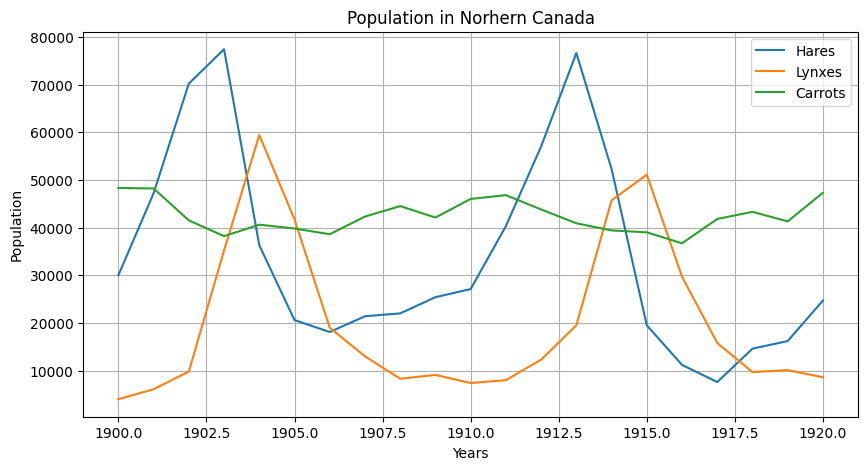

In [6]:
years = data[:, 0]
hares = data[:, 1]
lynxes = data[:, 2]
carrots = data[:, 3]

plt.figure(figsize = (10, 5))
plt.plot(years, hares, label = 'Hares')
plt.plot(years, lynxes, label = 'Lynxes')
plt.plot(years, carrots, label = 'Carrots')

plt.xlabel('Years')
plt.ylabel('Population')
plt.title('Population in Norhern Canada')
plt.legend()
plt.grid(True)
plt.show()

- Find which year each species had the largest population. Mark these years in the plot of populations.

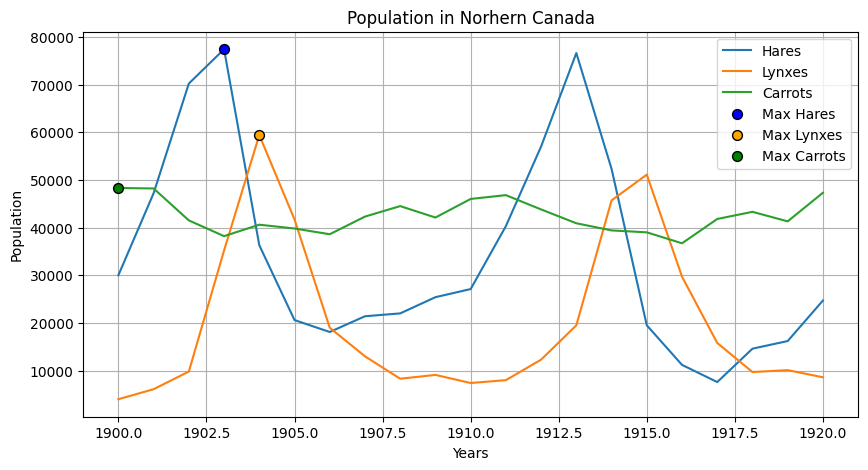

In [7]:
years = data[:, 0]
hares = data[:, 1]
lynxes = data[:, 2]
carrots = data[:, 3]

plt.figure(figsize = (10, 5))
plt.plot(years, hares, label = 'Hares')
plt.plot(years, lynxes, label = 'Lynxes')
plt.plot(years, carrots, label = 'Carrots')

plt.xlabel('Years')
plt.ylabel('Population')
plt.title('Population in Norhern Canada')
plt.legend()
plt.grid(True)

hares_idx = hares.argmax()
carrots_idx = carrots.argmax()
lynxes_idx = lynxes.argmax()

year_hares = years[hares_idx]
year_carrots = years[carrots_idx]
year_lynxes = years[lynxes_idx]

plt.scatter(year_hares, hares.max(), color='blue', label='Max Hares', s=50, edgecolors='black', zorder=5)
plt.scatter(year_lynxes, lynxes.max(), color='orange', label='Max Lynxes', s=50, edgecolors='black', zorder=5)
plt.scatter(year_carrots, carrots.max(), color='green', label='Max Carrots', s=50, edgecolors='black', zorder=5)

plt.legend()
plt.show()

- Assuming total population of hares and lynxes is 100%, plot stacked bar graph showing ratio of each specis for each year in the period.

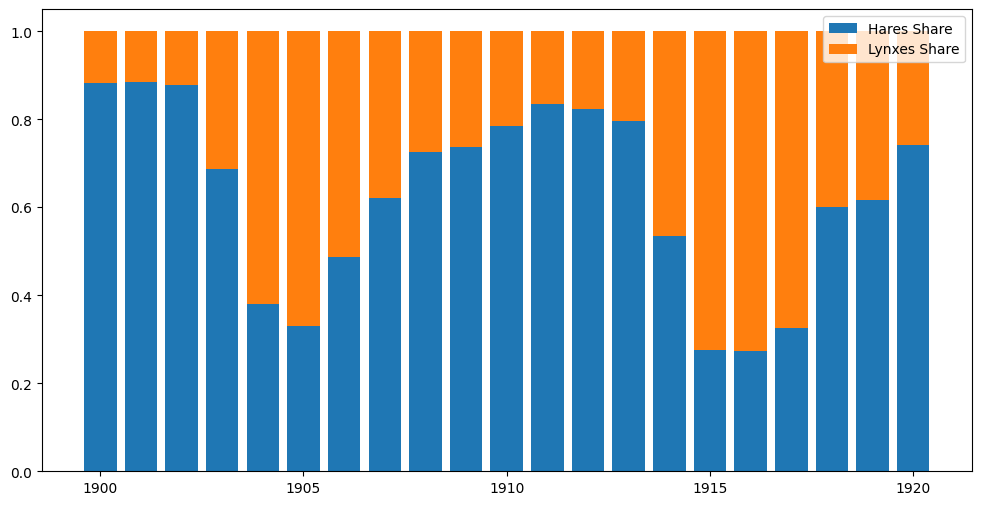

In [8]:
total = hares + lynxes
hare_percentage = hares / total
lynxes_percentage = lynxes / total

plt.figure(figsize = (12,6))
plt.bar(years, hare_percentage, label='Hares Share', color='C0')
plt.bar(years, lynxes_percentage, label = 'Lynxes Share', bottom = hare_percentage, color = 'C1')

plt.legend()

- Find the mean and std of the populations of each species. Plot the historgam of population for each species and show mean values with vertical line. Show each histogram in a separate plot. Arrange 3 plots in a row.

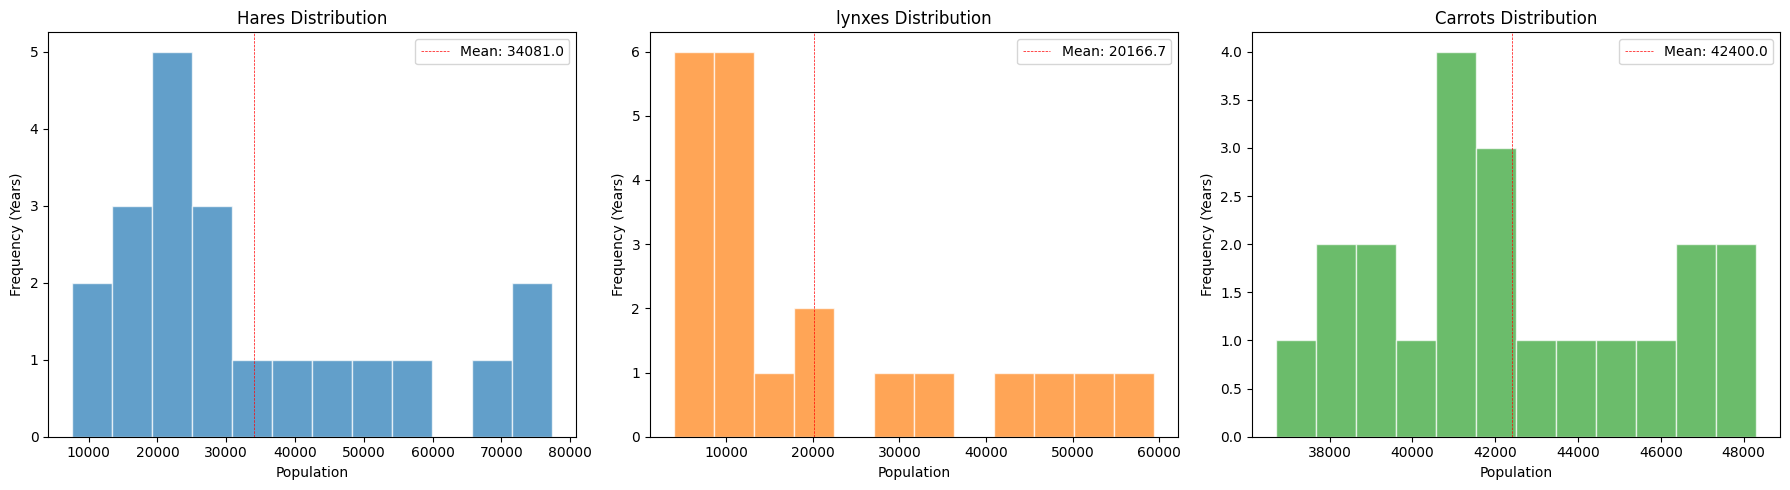

In [13]:
hares_mean, hares_std = hares.mean(), hares.std()
lynxes_mean, lynxes_std = lynxes.mean(), lynxes.std()
carrots_mean, carrots_std = carrots.mean(), carrots.std()

plt.figure(figsize = (18,5))
plt.subplot(1, 3, 1)
plt.hist(hares, bins = 12, color = 'C0', alpha = 0.7, edgecolor='white')
plt.axvline(hares_mean, color = 'Red', ls = '--', lw = 0.5, label = f'Mean: {hares_mean:.1f}')

plt.title('Hares Distribution')
plt.xlabel('Population')
plt.ylabel('Frequency (Years)')

plt.legend()

plt.subplot(1, 3, 2)
plt.hist(lynxes, bins = 12, color = 'C1', alpha = 0.7, edgecolor='white')
plt.axvline(lynxes_mean, color = 'Red', ls = '--', lw = 0.5, label = f'Mean: {lynxes_mean:.1f}')

plt.title('lynxes Distribution')
plt.xlabel('Population')
plt.ylabel('Frequency (Years)')

plt.legend()

plt.subplot(1, 3, 3)
plt.hist(carrots, bins = 12, color = 'C2', alpha = 0.7, edgecolor='white')
plt.axvline(carrots_mean, color = 'Red', ls = '--', lw = 0.5, label = f'Mean: {carrots_mean:.1f}')

plt.title('Carrots Distribution')
plt.xlabel('Population')
plt.ylabel('Frequency (Years)')

plt.tight_layout()
plt.legend()

- Find which species (hares or lynxes) has the largest population for each year. Print the result as [H, H, L, H, ...]. Plot a pie chart showing the ratio of "H" and "L" values.

['H' 'H' 'H' 'H' 'L' 'L' 'L' 'H' 'H' 'H' 'H' 'H' 'H' 'H' 'H' 'L' 'L' 'L'
 'H' 'H' 'H']


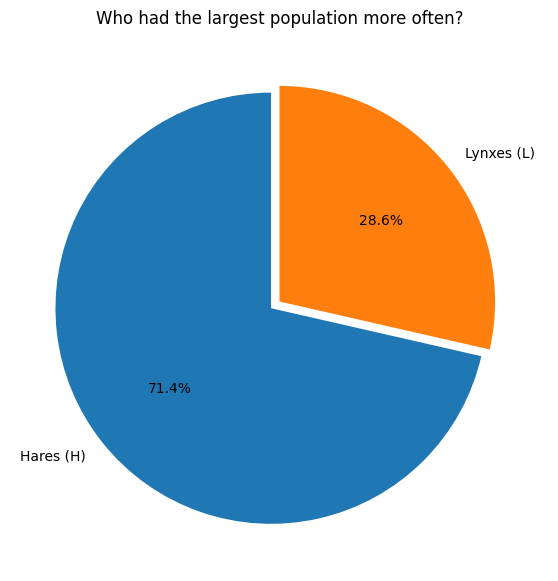

In [27]:
mask = hares > lynxes
result = np.where(mask, 'H', 'L')
print(result)

num_hares = np.sum(mask)
num_lynxes = len(result) - num_hares

plt.figure(figsize=(7, 7))

plt.pie([num_hares, num_lynxes],
        labels=['Hares (H)', 'Lynxes (L)'],
        autopct='%1.1f%%',
        colors=['C0', 'C1'],
        startangle=90,
        explode=(0.05, 0))

plt.title('Who had the largest population more often?')
plt.show()

- Plot the change in the hare population and in the lynx population for each year. Find the correlation coefficient between the both time series.

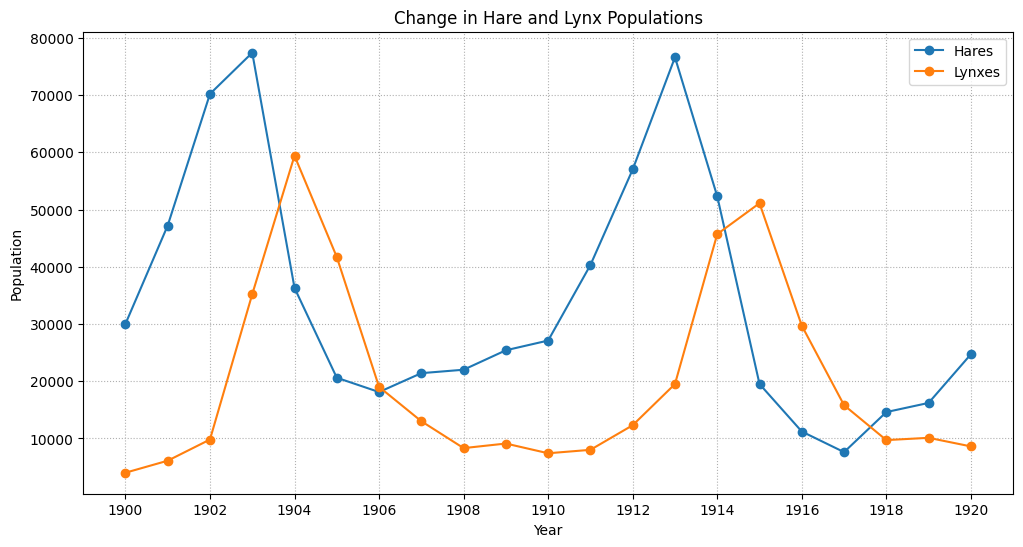

Correlation coefficient between hares and lynxes: 0.072


In [35]:
plt.figure(figsize=(12, 6))
plt.plot(years, hares, label='Hares', marker='o', color='C0')
plt.plot(years, lynxes, label='Lynxes', marker='o', color='C1')

plt.title('Change in Hare and Lynx Populations')
plt.xlabel('Year')
plt.ylabel('Population')
plt.xticks(years[::2])
plt.grid(True, ls=':')
plt.legend()
plt.show()

correlation_matrix = np.corrcoef(hares, lynxes)
correlation_coeff = correlation_matrix[0, 1]

print(f"Correlation coefficient between hares and lynxes: {correlation_coeff:.3f}")

- Using a scatter plot, show the population of hares vs lynxes by year (each point corresponds to a particular year, and the point coordinates correspond to the population of the two species in that year).

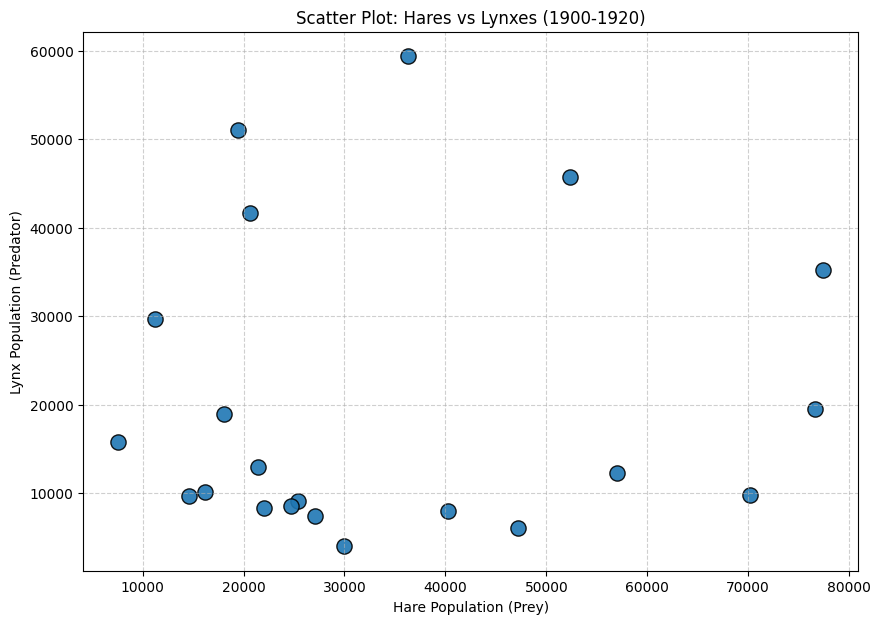

In [36]:
plt.figure(figsize=(10, 7))


scatter = plt.scatter(hares, lynxes, s=120, edgecolors='black', alpha=0.9)
plt.xlabel('Hare Population (Prey)')
plt.ylabel('Lynx Population (Predator)')
plt.title('Scatter Plot: Hares vs Lynxes (1900-1920)')
plt.grid(True, linestyle='--', alpha=0.6)

- Assume the population of hares in 1920 is unknown. Suggest a way to estimate this value. Compare an estimated value
with the true value and print a ratio of the error to the true value.

In [37]:
#Я решил заполнить средним значением

true_value = hares[-1]
estimated_value = hares[:-1].mean()
error = abs(true_value - estimated_value)
error_ratio = error / true_value

print(f"Реальное значение (1920): {true_value}")
print(f"Оценка (среднее): {estimated_value:.1f}")
print(f"Отношение ошибки к истине: {error_ratio:.2%}") # Вывод в процента

Реальное значение (1920): 24700.0
Оценка (среднее): 34550.0
Отношение ошибки к истине: 39.88%
